# SEM Image Segmentation

In [ ]:
!pip install imagecodecs # Run on once on first open

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 66.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, morphology, measure, segmentation, filters
from skimage.segmentation import find_boundaries, clear_border
from scipy import ndimage as ndi
import cv2
# Only needs to run once on first open

# Load image path here

In [439]:
img_path = "/content/MBE3-260408A-MM-MM_120000x_0.1nA_TLD_0007.tif"  # change this

In [424]:
filename = (img_path.split("/")[-1]).split(".tif")[0]
print(filename)

# look through the tiff metadata to find pixel calibration
# it's called pixelwidth easiest to use ctrl + f
import tifffile
from pprint import pprint
with tifffile.TiffFile(img_path) as tif:

    page = tif.pages[0]

    fei = page.tags["FEI_HELIOS"].value

    pprint(fei, compact=True, depth=2)

MBE3-260408A-MM-MM_120000x_0.1nA_TLD_0007
{'Accessories': {'Number': 0},
 'Beam': {'Beam': 'EBeam',
          'BeamShiftX': 0,
          'BeamShiftY': 0,
          'FineStageBias': 0,
          'HV': 5000,
          'ImageMode': 'Normal',
          'Scan': 'EScan',
          'ScanRotation': 0,
          'Spot': -3,
          'StigmatorX': 0.279375,
          'StigmatorY': 0.129319},
 'Detectors': {'Mode': 'SE', 'Name': 'TLD', 'Number': 1},
 'EBeam': {'ATubeVoltage': '',
           'Acq': 'PIA 3.0',
           'Aperture': 'AVA',
           'ApertureDiameter': 8e-06,
           'BeamCurrent': 1e-10,
           'BeamMode': 'N-Beam',
           'BeamShiftX': 0,
           'BeamShiftY': 0,
           'ColumnType': 'Elstar',
           'DynamicFocusIsOn': 'no',
           'DynamicWDIsOn': '',
           'EmissionCurrent': '',
           'EucWD': 0.00402206,
           'FinalLens': 'Elstar',
           'HFW': 3.45333e-06,
           'HV': 5000,
           'ImageMode': 'Normal',
           'Le

# Make sure to update pixel size

In [425]:
pixel_size_m = 2.24826e-09 # copy and paste pixel width here
pixel_size_um = pixel_size_m * 1000000
pixel_size_nm = pixel_size_m * 1000000000
print(f"Pixel size in microns: {pixel_size_um} um")
print(f"Pixel size in nanometers: {pixel_size_nm} nm")

Pixel size in microns: 0.0022482599999999998 um
Pixel size in nanometers: 2.2482599999999997 nm


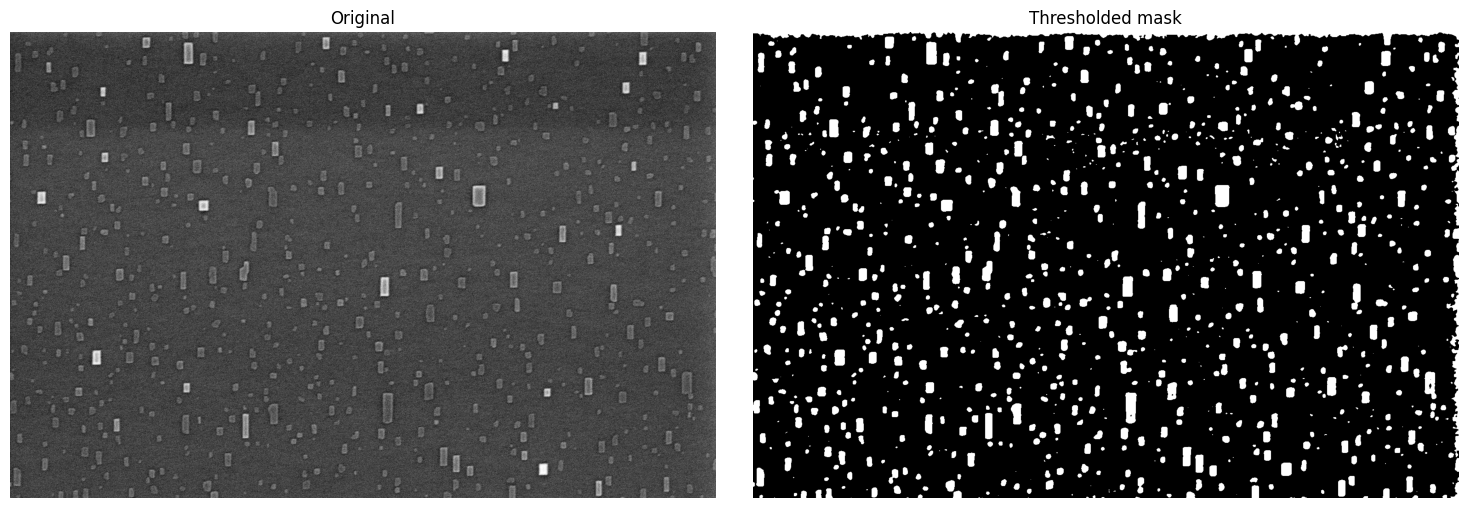

In [430]:
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Remove SEM info bar at bottom
img = img[:-80, :] # change if needed to crop more or less.


# Slight smoothing
blur = filters.gaussian(img, sigma=2.2) # keep sigma as low as possible to reduce smoothing

local_thresh = filters.threshold_local(
    blur,
    block_size=201,   # try 101-401 must be odd
    offset=-0.015 # this is threshhold strength try between -0.02 and 0
)

binary = blur > local_thresh
binary1 = binary

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(binary, cmap="gray")
ax[1].set_title("Thresholded mask")


for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

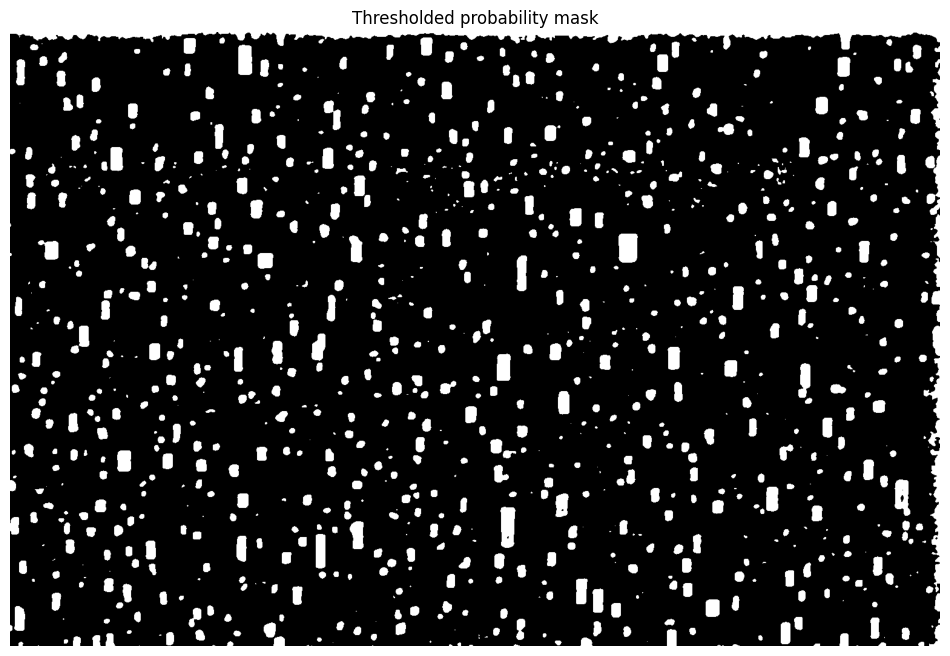

In [431]:
binary = binary1

plt.figure(figsize=(12, 8))
plt.imshow(binary, cmap="gray", vmin=0, vmax=1)
plt.title("Thresholded probability mask")
plt.axis("off")
plt.show()

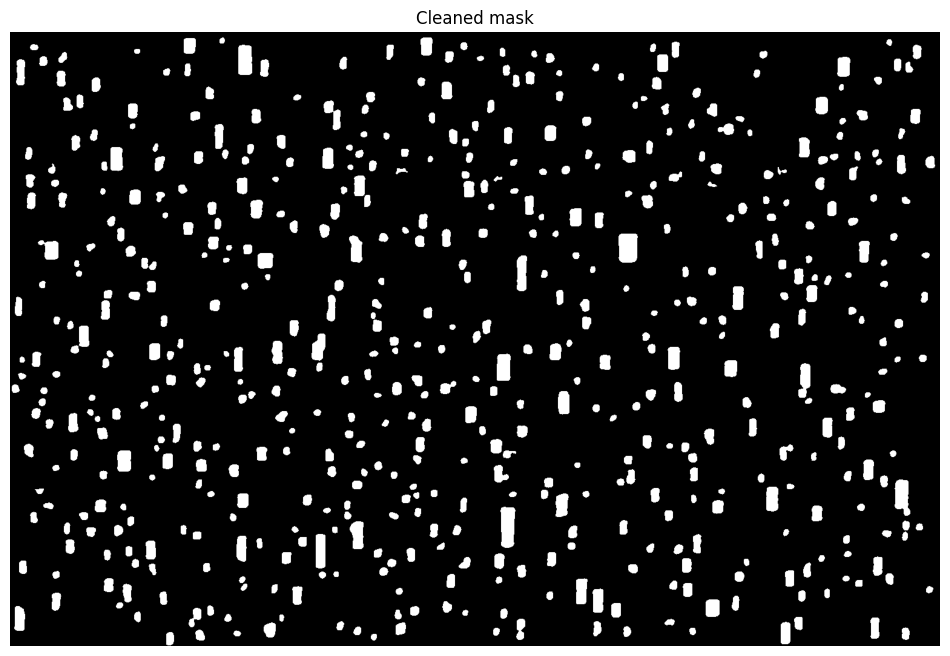

In [432]:
mask = binary.copy()
# remove tiny noise
clean = morphology.remove_small_objects(mask, min_size=50) # pre filtering adjust if too agressive
# connect fragmented edges
clean = morphology.binary_closing(clean, morphology.disk(0)) #  don't go higher than 1 as it will merge features must be integer

# fill interiors
clean = ndi.binary_fill_holes(clean)

# smooth slightly
clean = morphology.binary_opening(clean, morphology.disk(0))
clean = morphology.remove_small_holes(clean, area_threshold=10000) # change this if feature shape is altered too much usually fine

clean = morphology.remove_small_objects(clean, min_size=70) # play around this this until it looks right

clean = clear_border(clean) # remove objects touching edge



plt.figure(figsize=(12, 8))
plt.imshow(clean, cmap="gray", vmin=0, vmax=1)
plt.title("Cleaned mask")
plt.axis("off")
plt.show()

# These are the feature labels that are used when manually removing features.

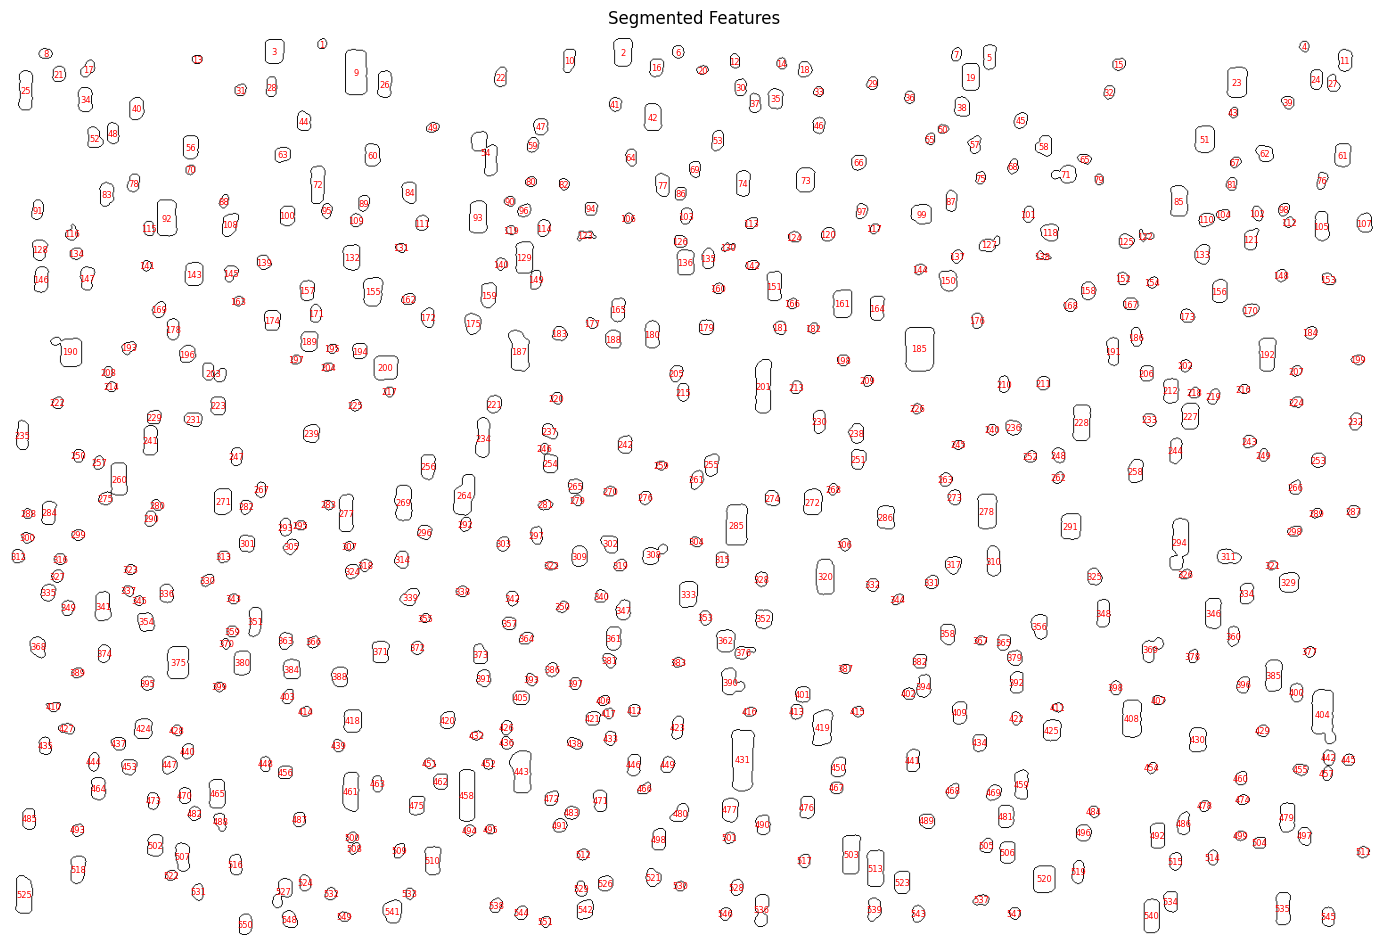

In [433]:
# label objects
labels = measure.label(clean)

# create white background
display = np.ones((*clean.shape, 3))

# find borders
borders = find_boundaries(labels, mode='outer')

# draw black borders
display[borders] = [0, 0, 0]

fig, ax = plt.subplots(figsize=(14, 10))

ax.imshow(display)

# label each object
props = measure.regionprops(labels)

for prop in props:
    y, x = prop.centroid

    ax.text(
        x,
        y,
        str(prop.label),
        color='red',
        fontsize=6,
        ha='center',
        va='center'
    )

ax.set_title("Segmented Features")
ax.axis("off")

plt.tight_layout()
plt.show()

In [434]:
props = measure.regionprops_table(
    labels,
    properties=[
        "label",
        "area",
        "perimeter",
        "solidity",
        "major_axis_length",
        "minor_axis_length",
    ]
)

df = pd.DataFrame(props)

df["aspect_ratio"] = df["major_axis_length"] / df["minor_axis_length"]
df["circularity"] = 4 * np.pi * df["area"] / (df["perimeter"] ** 2)

# adjust these thresholds as a last resort
keep = (
    (df["area"] > 7) &
    (df["solidity"] > 0.80) &
    (df["circularity"] > 0.12)
    # (df["aspect_ratio"] < 10)
)


good_labels = df.loc[keep, "label"].values

# PAY ATTENTION TO THIS
manual_removed = [] # GO BACK AND CHANGE THIS FOR EACH SAMPLE!!

filtered = np.isin(labels, good_labels)
filtered = filtered & ~np.isin(labels, manual_removed)

# relabel after filtering
filtered_labels = measure.label(filtered)
filtered_df = df[df["label"].isin(good_labels)]

Removed labels:
[54, 122, 123, 203, 369, 527]
Removed 6 out of 551 objects


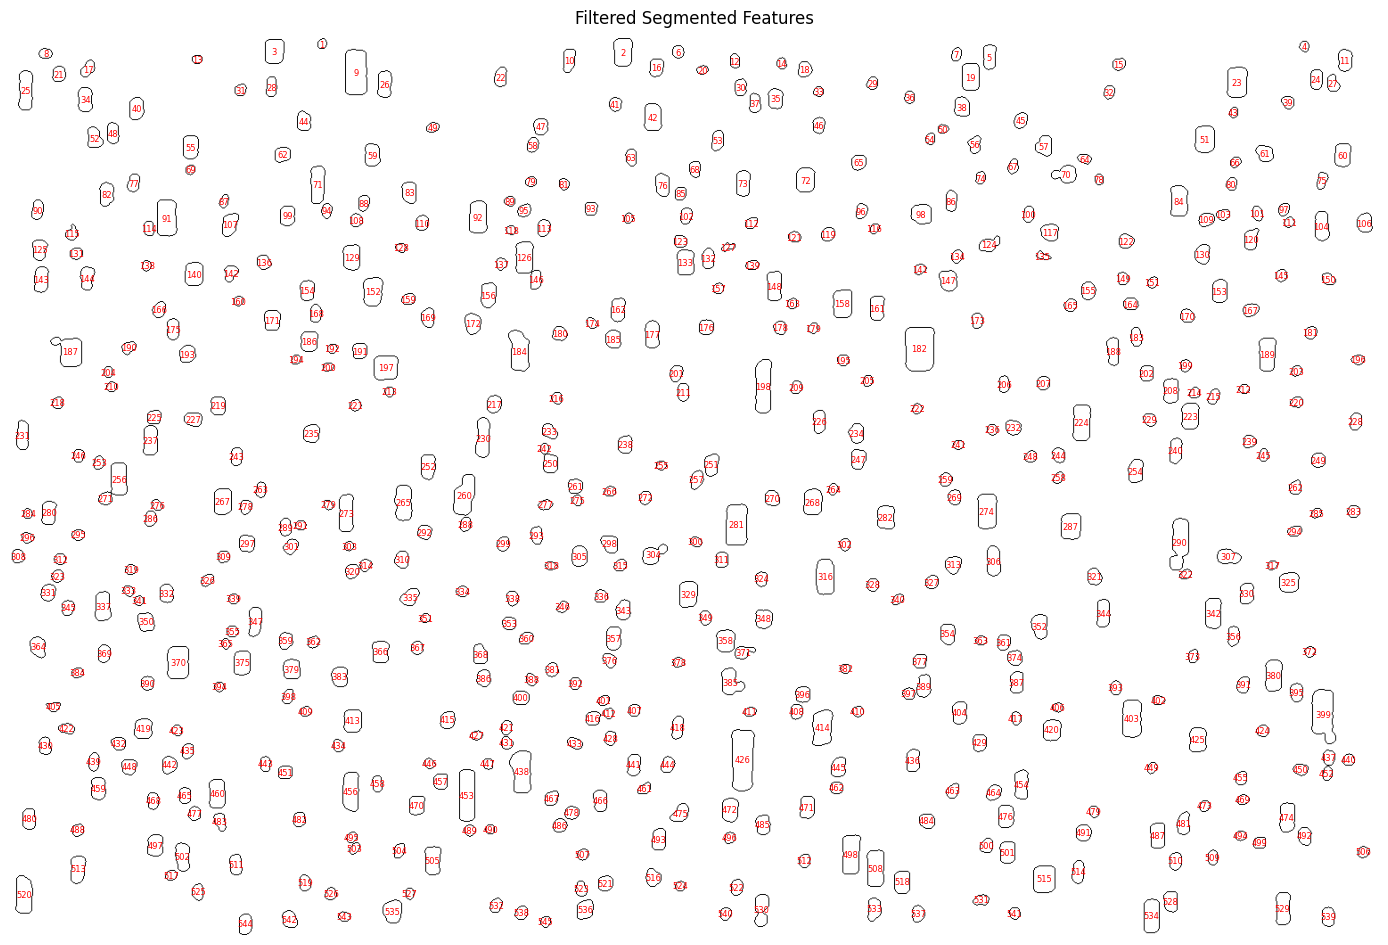

In [435]:
display = np.ones((*filtered.shape, 3))
borders = find_boundaries(filtered_labels, mode="outer")
display[borders] = [0, 0, 0]

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(display)

for prop in measure.regionprops(filtered_labels):
    y, x = prop.centroid
    ax.text(
        x, y, str(prop.label),
        color="red",
        fontsize=6,
        ha="center",
        va="center"
    )

all_labels = set(df["label"])
kept_labels = set(good_labels)

removed_labels = sorted(all_labels - kept_labels )

removed_labels = removed_labels + manual_removed

print("Removed labels:")
print(removed_labels)
print(f"Removed {len(removed_labels)} out of {len(all_labels)} objects")


ax.set_title("Filtered Segmented Features")
ax.axis("off")
plt.tight_layout()
plt.show()

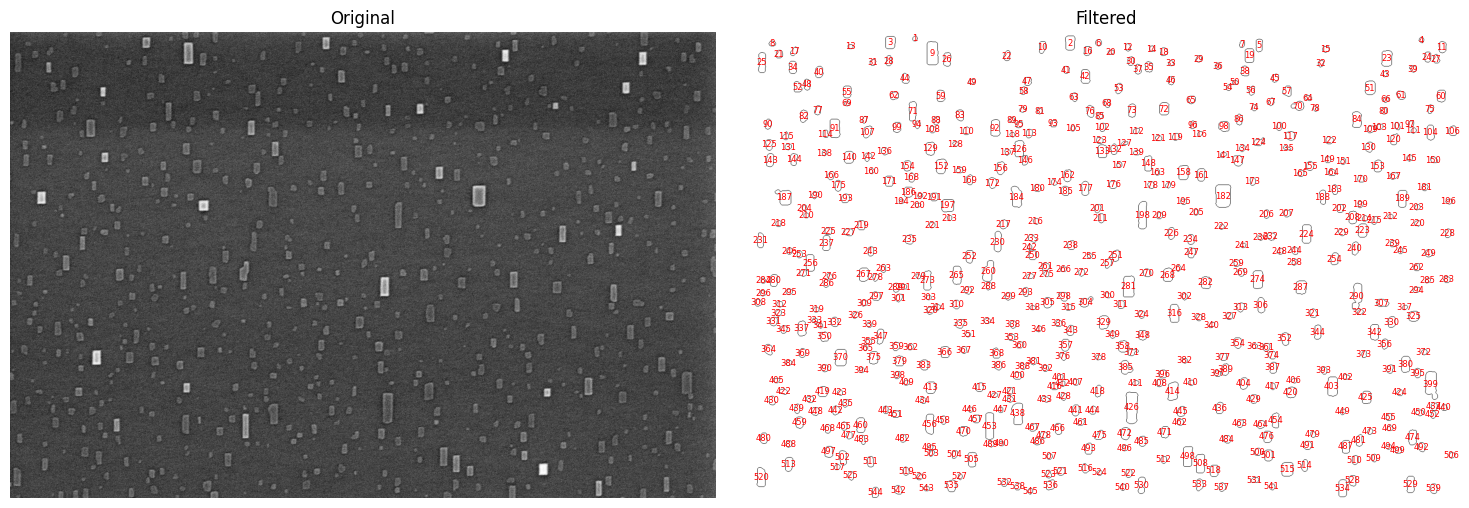

In [447]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(display, cmap="gray")
ax[1].set_title("Filtered")
ax[1].axis("off")

for prop in measure.regionprops(filtered_labels):
    y, x = prop.centroid
    ax[1].text(
        x, y, str(prop.label),
        color="red",
        fontsize=6,
        ha="center",
        va="center"
    )



plt.tight_layout()
plt.show()


In [436]:
df = filtered_df
df["length_um"] = df["major_axis_length"] * pixel_size_um
df["width_um"] = df["minor_axis_length"] * pixel_size_um
df["area_um2"] = df["area"] * pixel_size_um**2
df["length_nm"] = df["major_axis_length"] * pixel_size_nm
df["width_nm"] = df["minor_axis_length"] * pixel_size_nm
df["area_nm2"] = df["area"] * pixel_size_nm**2
df["scan_width"] = img.shape[1] * pixel_size_um
df["scan_height"] = img.shape[0] * pixel_size_um
df.head()

,label,area,perimeter,solidity,major_axis_length,minor_axis_length,aspect_ratio,circularity,length_um,width_um,area_um2,length_nm,width_nm,area_nm2,scan_width,scan_height
0,1,74.0,29.313708,0.961039,10.562366,8.920453,1.184062,1.082181,0.023747,0.020055,0.000374,23.746945,20.055497,374.045804,3.453327,2.279736
1,2,539.0,88.970563,0.962500,33.652705,21.050642,1.598655,0.855669,0.075660,0.047327,0.002724,75.660030,47.327317,2724.468762,3.453327,2.279736
2,3,490.0,82.142136,0.985915,29.066576,21.977857,1.322539,0.912586,0.065349,0.049412,0.002477,65.349220,49.411937,2476.789784,3.453327,2.279736
3,4,82.0,31.556349,0.953488,11.081914,9.503761,1.166056,1.034785,0.024915,0.021367,0.000414,24.915023,21.366925,414.483188,3.453327,2.279736
4,5,303.0,70.384776,0.952830,29.123348,13.655226,2.132762,0.768591,0.065477,0.030700,0.001532,65.476858,30.700499,1531.565927,3.453327,2.279736


In [437]:
print(filename)
df.to_csv(f"grain_statistics_{filename}.csv", index=False)
stat_path = f"/content/grain_statistics_{filename}.csv"

MBE3-260408A-MM-MM_120000x_0.1nA_TLD_0007


In [438]:
path = stat_path
# path = "/content/grain_statistics_MBE3-260512A-MM_120000x_TLD_0.1nA_5kV_034 (1).csv"
df = pd.read_csv(path)

num_grains = len(df)
summary = {
    "sample_id": path.split("_")[2],
    "num_grains": num_grains,
    "mean_length": df["length_nm"].mean(),
    "std_length": df["length_nm"].std(),
    "mean_width": df["width_nm"].mean(),
    "std_width": df["width_nm"].std(),

}

summary =  pd.DataFrame(summary, index=[0])
summary

,sample_id,num_grains,mean_length,std_length,mean_width,std_width
0,MBE3-260408A-MM-MM,545,46.026728,22.051819,30.281189,8.624557
